← [Votación y decisión](10-votacion-y-decision.ipynb) · [Índice](00-indice.ipynb) · Siguiente: [Del modelo al robot](12-del-modelo-al-robot.ipynb) →

# 11 · Cómo se mide

El documento [08](08-cambio-de-dominio.ipynb) mostró que una métrica alta puede no
significar nada. Este explica cómo se mide bien.



## Las tres particiones

Un dataset se parte en tres, y cada parte tiene un trabajo distinto:

| Partición | Para qué | ¿Se consulta? |
| --- | --- | --- |
| **Entrenamiento** | Ajustar los parámetros del modelo | Constantemente |
| **Validación** | Elegir entre alternativas: arquitectura, épocas, umbrales | En cada decisión |
| **Prueba** | Estimar el rendimiento real | **Una sola vez, al final** |

La razón de que sean tres y no dos: en cuanto usas un conjunto para **decidir**
algo, dejas de poder usarlo para **estimar**. Si eliges el modelo que mejor sale
en validación, esa cifra ya está optimizada — se le pegó algo de la suerte de
ese conjunto concreto.

La prueba existe para responder "¿cuánto rinde de verdad?" sin contaminación. Y
solo funciona si de verdad se consulta una vez. En Reci eso está forzado por
código: `evaluar_ganador.py` se niega a sobrescribir `prueba_metricas.json`.

El dataset de trabajo actual:

| Conjunto | Plástico | Vidrio |
| --- | ---: | ---: |
| Entrenamiento | 8.765 | 8.865 |
| Validación | 100 | 99 |
| Prueba | 100 | 100 |
| Auditoría | 0 | 1 |



## Fuga de datos

Es el error más fácil de cometer y el más difícil de detectar. Ocurre cuando
información del conjunto de prueba se filtra al entrenamiento.

**El caso concreto de Reci:** la ESP32-CAM captura ráfagas de fotos casi
idénticas, dos segundos aparte. Si se repartieran al azar, la foto 001 caería en
entrenamiento y la 002 en prueba. El modelo la reconocería de memoria y la
prueba daría un número altísimo que no mide generalización, sino memoria.

Por eso la partición de Reci se hace **por sesión completa**: todas las fotos de
una misma ráfaga van juntas al mismo conjunto. `split_manifest.json` registra la
asignación y el cargador rechaza el dataset si detecta una sesión partida entre
dos conjuntos, o un mismo SHA-256 en dos sitios.

La regla general: **divide por la unidad que se repite**, no por archivo. Si hay
varias fotos por objeto, divide por objeto. Si hay varias sesiones, por sesión.



## Por qué la exactitud engaña

La exactitud (*accuracy*) es la fracción de aciertos. Su problema es que
**promedia sobre las clases** y puede esconder que una funciona mal:

```
plástico:  60,60 % de recall
vidrio:    82,60 % de recall
exactitud global: 71,60 %
```

El 71,60 % suena mediocre pero uniforme. La realidad es que el modelo apenas
reconocía plástico. Ese detalle —el que importa para el robot— desaparece del
promedio.



## Las métricas que sí sirven

### Matriz de confusión

Muestra **qué se confunde con qué**:

```
                 predijo plástico   predijo vidrio
  real plástico            2.299               44
  real vidrio                 29            2.275
```

La diagonal son los aciertos; todo lo demás son errores, y su posición dice de
qué tipo.

### Precisión y recall

Dos preguntas distintas sobre la misma clase:

- **Precisión:** de todo lo que llamé vidrio, ¿cuánto era vidrio de verdad?
- **Recall:** de todo el vidrio que había, ¿cuánto encontré?

Se pueden manipular por separado. Un modelo que dijera "vidrio" a todo tendría
recall de vidrio del 100 % y precisión pésima.

### F1 y macro-F1

**F1** combina precisión y recall en un solo número (su media armónica), que es
alto solo si **ambas** lo son.

**Macro-F1** promedia el F1 de cada clase **dando el mismo peso a todas**. Es la
métrica principal de Reci, y la razón es directa: una clase que funciona mal
arrastra el macro-F1 hacia abajo, aunque la otra compense. Con la exactitud
global, no.

Por eso la selección de modelo y la parada temprana usan `val_macro_f1`.

### Errores con confianza alta

Métrica propia del proyecto, nacida del problema del documento
[08](08-cambio-de-dominio.ipynb): cuántos errores tuvieron confianza ≥ 0,90. Mide
si se puede confiar en la confianza — y en el modelo original, no se podía.



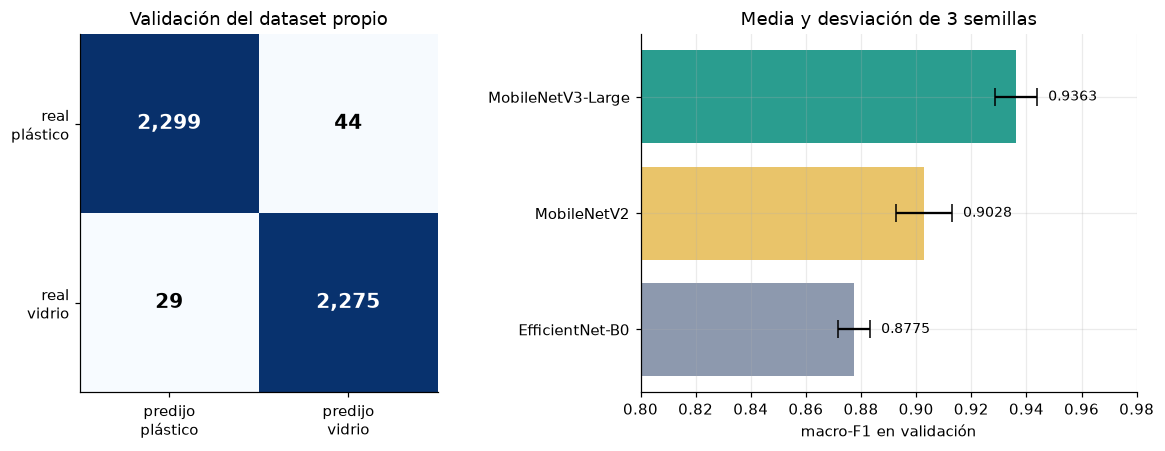

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

VIDRIO, PLASTICO, GRIS, ALERTA = "#2a9d8f", "#e9c46a", "#8d99ae", "#e76f51"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

# Matriz de confusión: dónde están los errores, no cuántos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

matriz = np.array([[2299, 44], [29, 2275]])
im = ax1.imshow(matriz, cmap="Blues")
ax1.set_xticks([0, 1]); ax1.set_xticklabels(["predijo\nplástico", "predijo\nvidrio"])
ax1.set_yticks([0, 1]); ax1.set_yticklabels(["real\nplástico", "real\nvidrio"])
ax1.set_title("Validación del dataset propio")
ax1.grid(False)
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f"{matriz[i, j]:,}", ha="center", va="center",
                 color="white" if matriz[i, j] > 1200 else "black",
                 fontsize=13, weight="bold")

# Tres semillas por arquitectura: la media sola no basta
arqs = ["EfficientNet-B0", "MobileNetV2", "MobileNetV3-Large"]
medias = [0.8775, 0.9028, 0.9363]
desv = [0.0058, 0.0102, 0.0076]
y = np.arange(len(arqs))
ax2.barh(y, medias, xerr=desv, color=[GRIS, PLASTICO, VIDRIO],
         capsize=6, error_kw=dict(lw=1.5))
ax2.set_yticks(y); ax2.set_yticklabels(arqs)
ax2.set(xlabel="macro-F1 en validación", xlim=(0.80, 0.98),
        title="Media y desviación de 3 semillas")
for i, (m, d) in enumerate(zip(medias, desv)):
    ax2.text(m + d + 0.004, i, f"{m:.4f}", va="center", fontsize=9)

plt.tight_layout(); plt.show()

## Semillas: no confiar en una sola corrida

Entrenar tiene azar: la inicialización, el orden de los lotes. Dos corridas del
mismo modelo con los mismos datos dan resultados algo distintos.

Por eso el protocolo exige **tres semillas por arquitectura** y reportar media y
desviación. Una sola corrida alta puede ser suerte.

Los resultados de las nueve corridas:

| Arquitectura | macro-F1 (media de 3) | desv. est. |
| --- | ---: | ---: |
| MobileNetV3-Large | 0,9363 | 0,0076 |
| MobileNetV2 | 0,9028 | 0,0102 |
| EfficientNet-B0 | 0,8775 | 0,0058 |

Aquí la separación es limpia: la peor semilla de MobileNetV3-Large (0,9296)
supera a la mejor de MobileNetV2 (0,9145). No hay solapamiento, así que la
ventaja es real y no ruido.



## Los criterios de aceptación

Tener buenas métricas no basta: hay que decidir de antemano qué cuenta como
"mejor", para no racionalizar el resultado después. La propuesta fija:

1. macro-F1 ≥ 85 % en la prueba independiente;
2. recall ≥ 85 % **en cada clase** — para que ninguna se esconda en el promedio;
3. mejora de **al menos 5 puntos** de macro-F1 frente al MobileNetV2 reentrenado;
4. sin regresión relevante tras exportar a TFLite;
5. latencia compatible con el equipo definitivo.

El criterio 3 es el que hoy no se cumple: `0,9363 − 0,9028 = 3,35 puntos`. Bajo
las reglas escritas, MobileNetV3-Large **no califica** para reemplazar al modelo
actual, pese a ganar en validación.

El criterio 4 es el tema del último documento.

---

← [Votación y decisión](10-votacion-y-decision.ipynb) · [Índice](00-indice.ipynb) · Siguiente: [Del modelo al robot](12-del-modelo-al-robot.ipynb) →
